In [3]:
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import us
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots


In [4]:
#read csv
mort_df = pd.read_csv('cdc_wonder_maternal_mortality_2021_2023_clean.csv')

In [5]:
mort_df['state'] = mort_df['state'].apply(
    lambda x: us.states.lookup(x).abbr if us.states.lookup(x) else x
)
mort_df['year'] = mort_df['year'].astype('Int64')

In [6]:
#widening dataframe so black, and white are columns
mort_df = (
    mort_df
    .pivot_table(
        index=['state', 'year'],
        columns='race',
        values=['deaths', 'population'],
        aggfunc='first'
    )
    .reset_index()
)
#flattening dataframe so that death, and population are their own columns, not values
mort_df.columns = [
    f"{race.lower().replace(' ', '_')}_{metric}"
    if metric in ['deaths', 'population']
    else metric
    for metric, race in mort_df.columns
]

In [7]:
# recalculating mortality rates and gap/ratio
mort_df['mortality_rate_black'] = (
    mort_df['black_or_african_american_deaths']
    / mort_df['black_or_african_american_population']
) * 100_000

mort_df['mortality_rate_white'] = (
    mort_df['white_deaths']
    / mort_df['white_population']
) * 100_000

mort_df['gap_black_minus_white'] = (
    mort_df['mortality_rate_black']
    - mort_df['mortality_rate_white']
)

mort_df['ratio_black_to_white'] = (
    mort_df['mortality_rate_black']
    / mort_df['mortality_rate_white']
)

In [8]:
#load df
df = pd.read_csv('hospitals_clean_2021_2023.csv')

In [9]:
#dropping hospital name -- ID is more useful if needed to compare year across year
df.drop('hospital_name', axis=1, inplace=True)
df['hospital_has_ehr_interoperability'] = (
    df['hospital_has_ehr_interoperability'].fillna(0)
)

In [10]:
#df to look at the avg emergency services count of every hospital combined in states over years
avg_stateYear = (
    df.assign(
        hospital_has_ehr_interoperability=
        df['hospital_has_ehr_interoperability'].fillna(0)
    )
    .groupby(['state', 'year'], as_index=False)[
        ['hospital_has_emergency_services',
         'hospital_has_ehr_interoperability']
    ]
    .mean()
    .rename(columns={
        'hospital_has_emergency_services': 'emergency_ratio',
        'hospital_has_ehr_interoperability': 'ehr_ratio'
    })
    .sort_values(['year', 'state'])
)

In [11]:
#merging mortality data and state hospital data together
state_year_df = mort_df.merge(
    avg_stateYear,
    on=['state', 'year'],
    how='left'
)
state_year_filtered = state_year_df.dropna(
    subset=['gap_black_minus_white', 'emergency_ratio', 'ehr_ratio']
)


In [12]:
cols = ['gap_black_minus_white', 'ratio_black_to_white', 'emergency_ratio']

for col in cols:
    print(f"\nColumn: {col}")
    for year in sorted(state_year_filtered['year'].unique()):
        df_year = state_year_filtered[state_year_filtered['year'] == year]
        min_idx = df_year[col].idxmin()
        max_idx = df_year[col].idxmax()
        #print(f"Year {year}:")
        #print(f"  Min: {df_year.loc[min_idx, col]} ({df_year.loc[min_idx, 'state']})")
        #print(f"  Max: {df_year.loc[max_idx, col]} ({df_year.loc[max_idx, 'state']})")



Column: gap_black_minus_white

Column: ratio_black_to_white

Column: emergency_ratio


In [13]:
#creating ranked sorted by gap values
rank_df_sorted = state_year_filtered.sort_values('gap_black_minus_white')

top_bottom = pd.concat([
    rank_df_sorted.head(10),
    rank_df_sorted.tail(10)
])

/var/folders/24/yv4cjz2j4qndh0jby_dyvm_00000gn/T/ipykernel_8186/2149928279.py:17: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


/var/folders/24/yv4cjz2j4qndh0jby_dyvm_00000gn/T/ipykernel_8186/2149928279.py:17: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


/var/folders/24/yv4cjz2j4qndh0jby_dyvm_00000gn/T/ipykernel_8186/2149928279.py:17: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




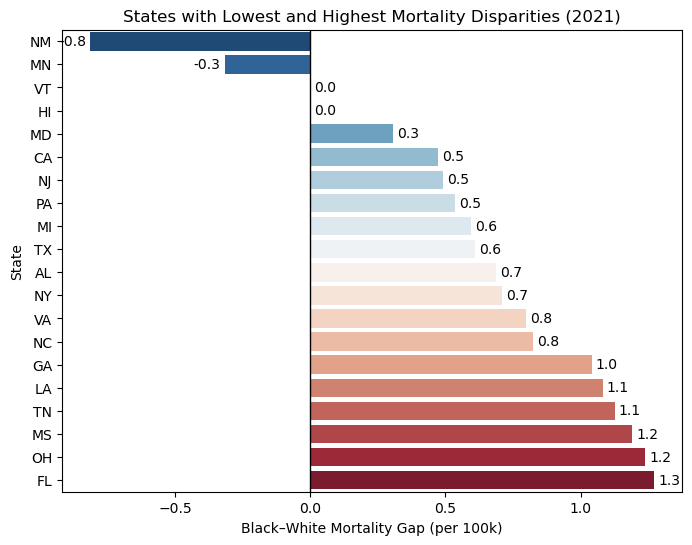

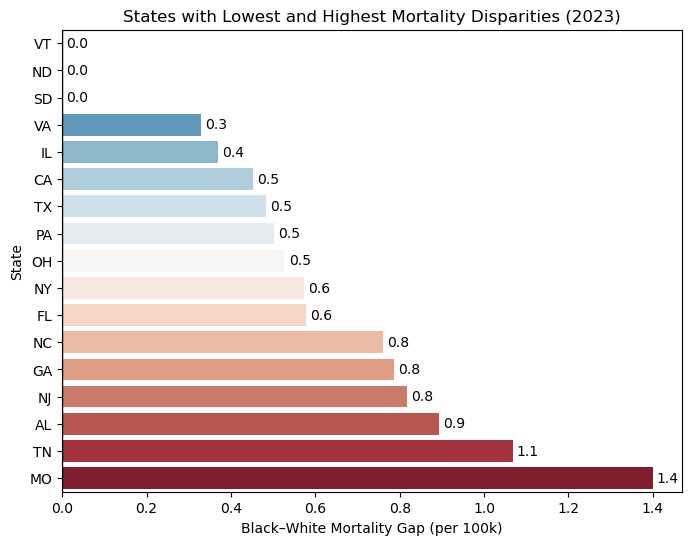

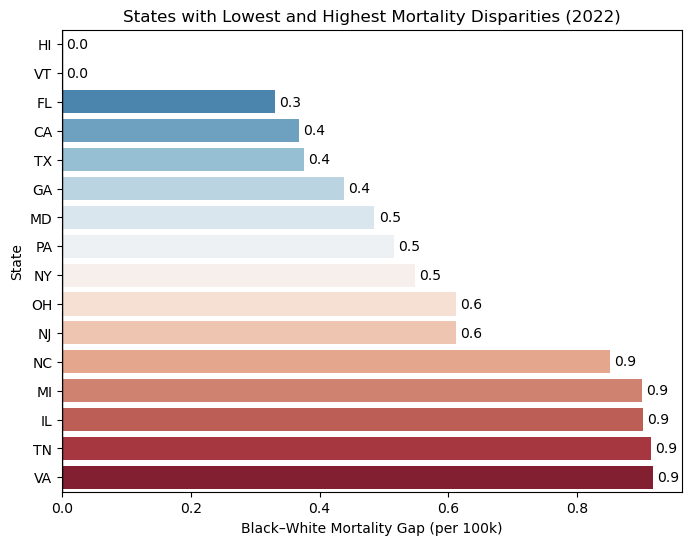

In [52]:
#ranked bar chart
years = state_year_filtered['year'].unique()

for yr in years:
    # Filter for this year
    df_year = state_year_filtered[state_year_filtered['year'] == yr]
    
    # Drop rows with NaN
    df_year = df_year.dropna(subset=['gap_black_minus_white'])
    
    # Sort and take top/bottom 10
    rank_sorted = df_year.sort_values('gap_black_minus_white')
    top_bottom = pd.concat([rank_sorted.head(10), rank_sorted.tail(10)])
    
    # Plot
    plt.figure(figsize=(8,6))
    ax = sns.barplot(
        data=top_bottom,
        y='state',
        x='gap_black_minus_white',
        palette='RdBu_r'
    )

    # >>> ADD THIS BLOCK <<<
    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%.1f",
            padding=3
        )
    # >>> END ADD <<<

    plt.axvline(0, color='black', linewidth=1)
    plt.xlabel('Black–White Mortality Gap (per 100k)')
    plt.ylabel('State')
    plt.title(f'States with Lowest and Highest Mortality Disparities ({yr})')
    #plt.savefig(f"mortality_gap_ranked{yr}.png", dpi=300) 
    #plt.show()


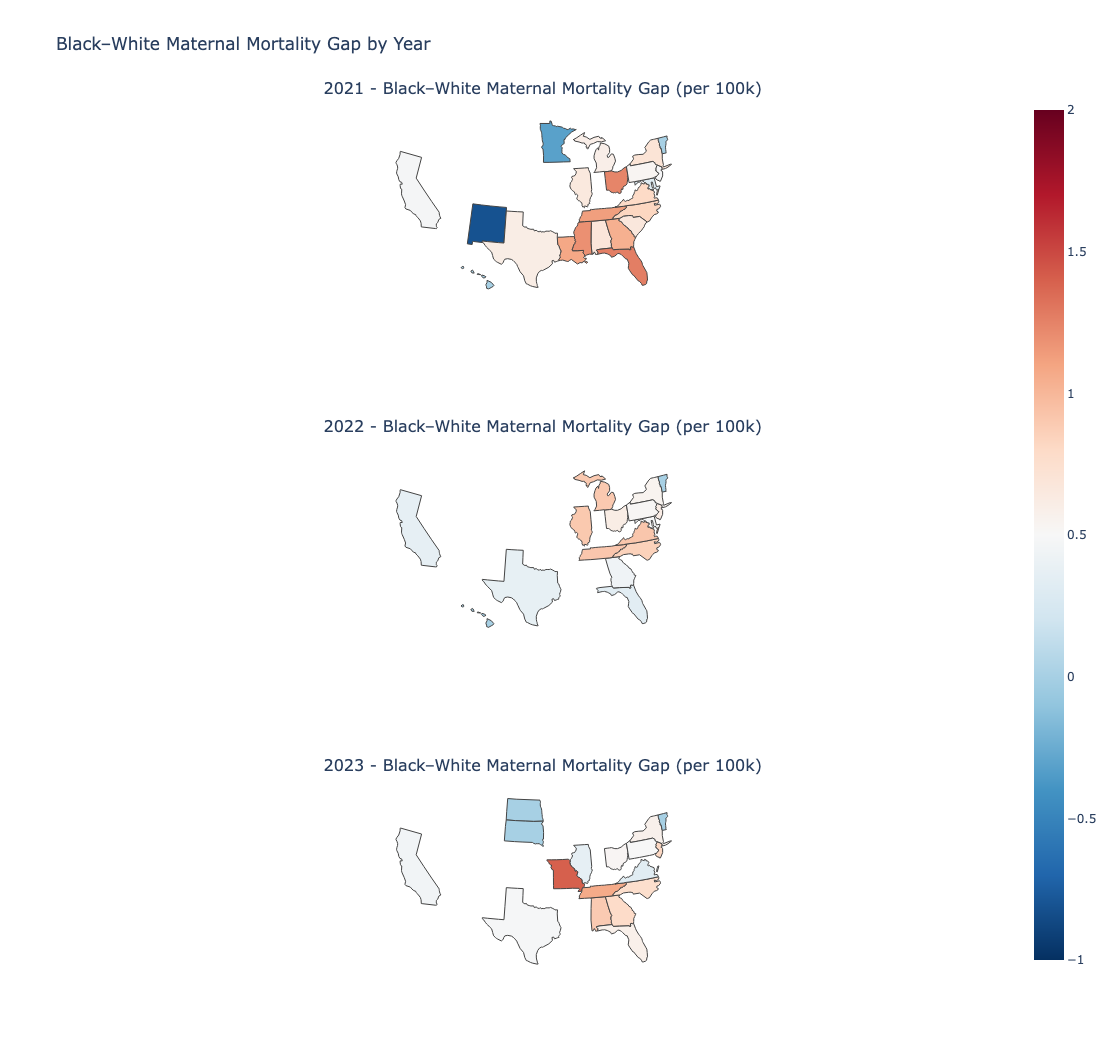

In [15]:
years = sorted(state_year_df['year'].unique())

fig_gap = make_subplots(
    rows=len(years), cols=1,
    specs=[[{"type": "choropleth"}] for _ in years],
    subplot_titles=[
        f"{year} - Black–White Maternal Mortality Gap (per 100k)"
        for year in years
    ]
)

for i, year in enumerate(years, start=1):
    df_year = state_year_df[state_year_df['year'] == year]

    fig_gap.add_trace(
        go.Choropleth(
            locations=df_year['state'],
            z=df_year['gap_black_minus_white'],
            locationmode='USA-states',
            colorscale='RdBu_r',
            zmin=-1,
            zmax=2,
            showscale=(i == 1)  # only show one colorbar
        ),
        row=i, col=1
    )

    fig_gap.update_geos(scope='usa', visible=False, row=i, col=1)

fig_gap.update_layout(
    title_text="Black–White Maternal Mortality Gap by Year",
    height=350 * len(years),
    width=800
)

#fig_gap.show()


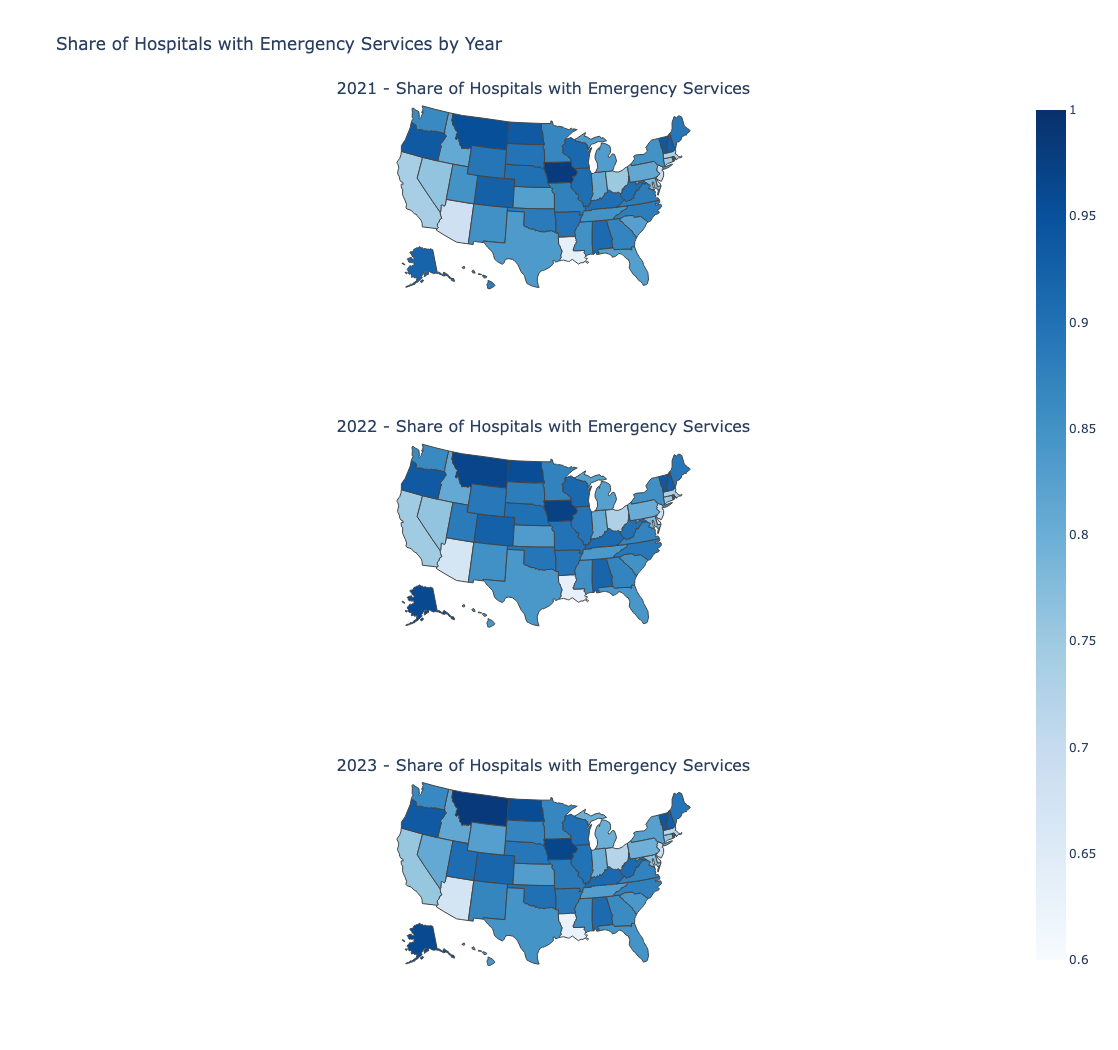

In [16]:
fig_emergency = make_subplots(
    rows=len(years), cols=1,
    specs=[[{"type": "choropleth"}] for _ in years],
    subplot_titles=[
        f"{year} - Share of Hospitals with Emergency Services"
        for year in years
    ]
)

for i, year in enumerate(years, start=1):
    df_year = state_year_df[state_year_df['year'] == year]

    fig_emergency.add_trace(
        go.Choropleth(
            locations=df_year['state'],
            z=df_year['emergency_ratio'],
            locationmode='USA-states',
            colorscale='Blues',
            zmin=0.6,
            zmax=1,
            showscale=(i == 1)
        ),
        row=i, col=1
    )

    fig_emergency.update_geos(scope='usa', visible=False, row=i, col=1)

fig_emergency.update_layout(
    title_text="Share of Hospitals with Emergency Services by Year",
    height=350 * len(years),
    width=800
)

fig_emergency.show()


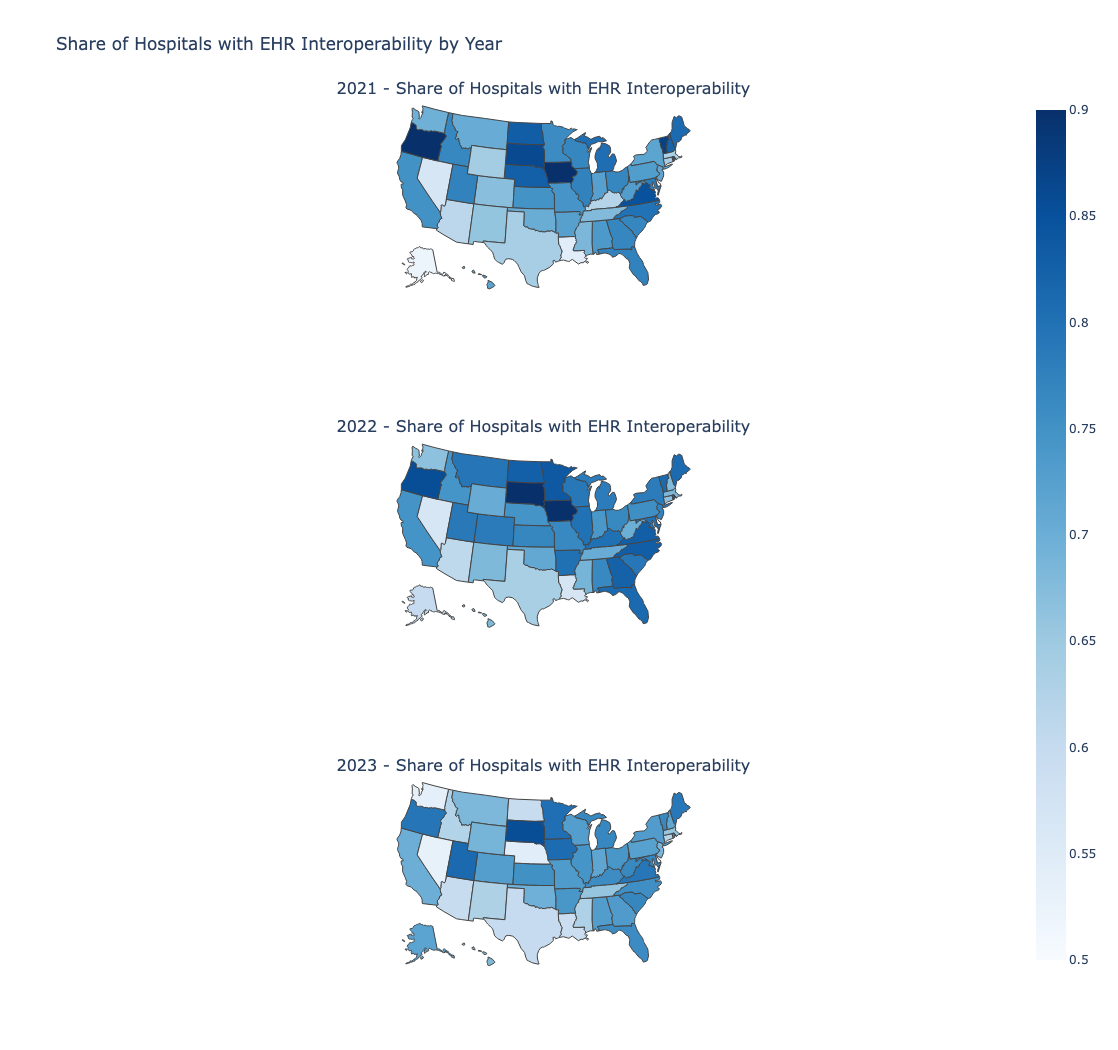

In [17]:
fig_ehr = make_subplots(
    rows=len(years), cols=1,
    specs=[[{"type": "choropleth"}] for _ in years],
    subplot_titles=[
        f"{year} - Share of Hospitals with EHR Interoperability"
        for year in years
    ]
)

for i, year in enumerate(years, start=1):
    df_year = state_year_df[state_year_df['year'] == year]

    fig_ehr.add_trace(
        go.Choropleth(
            locations=df_year['state'],
            z=df_year['ehr_ratio'], 
            locationmode='USA-states',
            colorscale='Blues',
            zmin=0.5,
            zmax=0.9,
            showscale=(i == 1)
        ),
        row=i, col=1
    )

    fig_ehr.update_geos(scope='usa', visible=False, row=i, col=1)

fig_ehr.update_layout(
    title_text="Share of Hospitals with EHR Interoperability by Year",
    height=350 * len(years),
    width=800
)

fig_ehr.show()


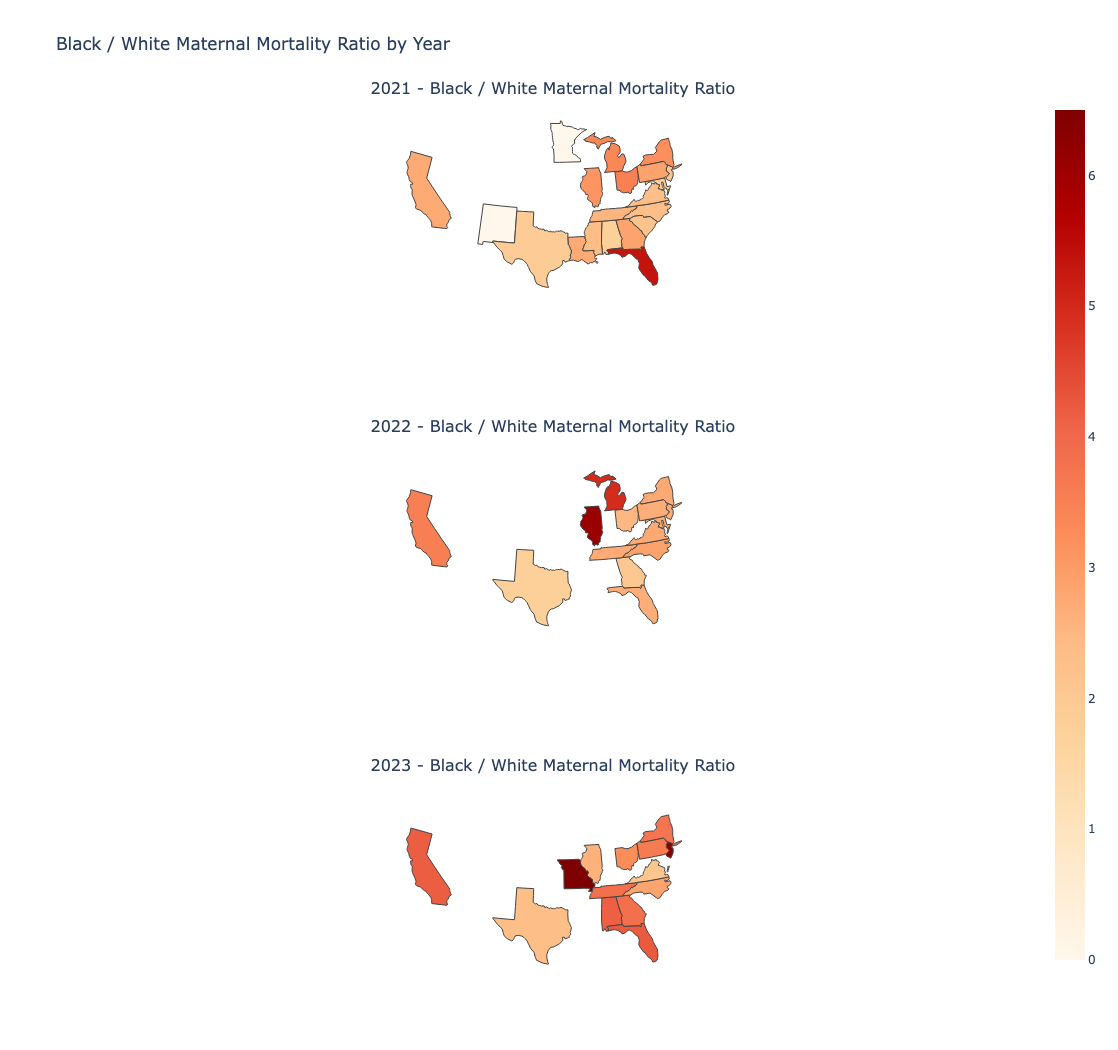

In [18]:
fig_ratio = make_subplots(
    rows=len(years), cols=1,
    specs=[[{"type": "choropleth"}] for _ in years],
    subplot_titles=[
        f"{year} - Black / White Maternal Mortality Ratio"
        for year in years
    ]
)

for i, year in enumerate(years, start=1):
    df_year = state_year_df[state_year_df['year'] == year]

    fig_ratio.add_trace(
        go.Choropleth(
            locations=df_year['state'],
            z=df_year['ratio_black_to_white'],
            locationmode='USA-states',
            colorscale='OrRd',
            zmin=0,
            zmax=6.5,
            showscale=(i == 1)
        ),
        row=i, col=1
    )

    fig_ratio.update_geos(scope='usa', visible=False, row=i, col=1)

fig_ratio.update_layout(
    title_text="Black / White Maternal Mortality Ratio by Year",
    height=350 * len(years),
    width=800
)

#fig_ratio.show()


In [19]:
# creating a dataframe to look at average ranking by state per hospital type
avg_rankingYearHospital = (
    df.groupby(['state', 'hospital_type', 'year'], as_index=False)['hospital_overall_rating']
      .mean()
      .rename(columns={'hospital_overall_rating': 'avg_hospital_rating'})
)

avg_rankingYearHospital = avg_rankingYearHospital.sort_values(['year', 'state', 'hospital_type'])

In [20]:
# df looking at the average ranking of all hospitals in a state over years
avg_rankingYear = (
    df.groupby(['state', 'year'], as_index=False)['hospital_overall_rating']
      .mean()
      .rename(columns={'hospital_overall_rating': 'avg_hospital_rating'})
)

avg_rankingYear= avg_rankingYear.sort_values(['year', 'state'])

In [21]:
us_states = [
    'AL','AK','AZ','AR','CA','CO','CT','DE','FL','GA','HI','ID','IL','IN','IA',
    'KS','KY','LA','ME','MD','MA','MI','MN','MS','MO','MT','NE','NV','NH','NJ',
    'NM','NY','NC','ND','OH','OK','OR','PA','RI','SC','SD','TN','TX','UT','VT',
    'VA','WA','WV','WI','WY'
]

cols = ['avg_hospital_rating']

#Code used to check Value of min/max numbers by state
for col in cols:
    print(f"\nColumn: {col}")
    for year in sorted(avg_rankingYear['year'].unique()):
        # Filter only actual states
        df_year = avg_rankingYear[
            (avg_rankingYear['year'] == year) &
            (avg_rankingYear['state'].isin(us_states))
        ]
        if df_year.empty:
            continue  # skip if no data
        min_idx = df_year[col].idxmin()
        max_idx = df_year[col].idxmax()
       # print(f"Year {year}:")
        #print(f"  Min: {df_year.loc[min_idx, col]} ({df_year.loc[min_idx, 'state']})")
       # print(f"  Max: {df_year.loc[max_idx, col]} ({df_year.loc[max_idx, 'state']})")



Column: avg_hospital_rating


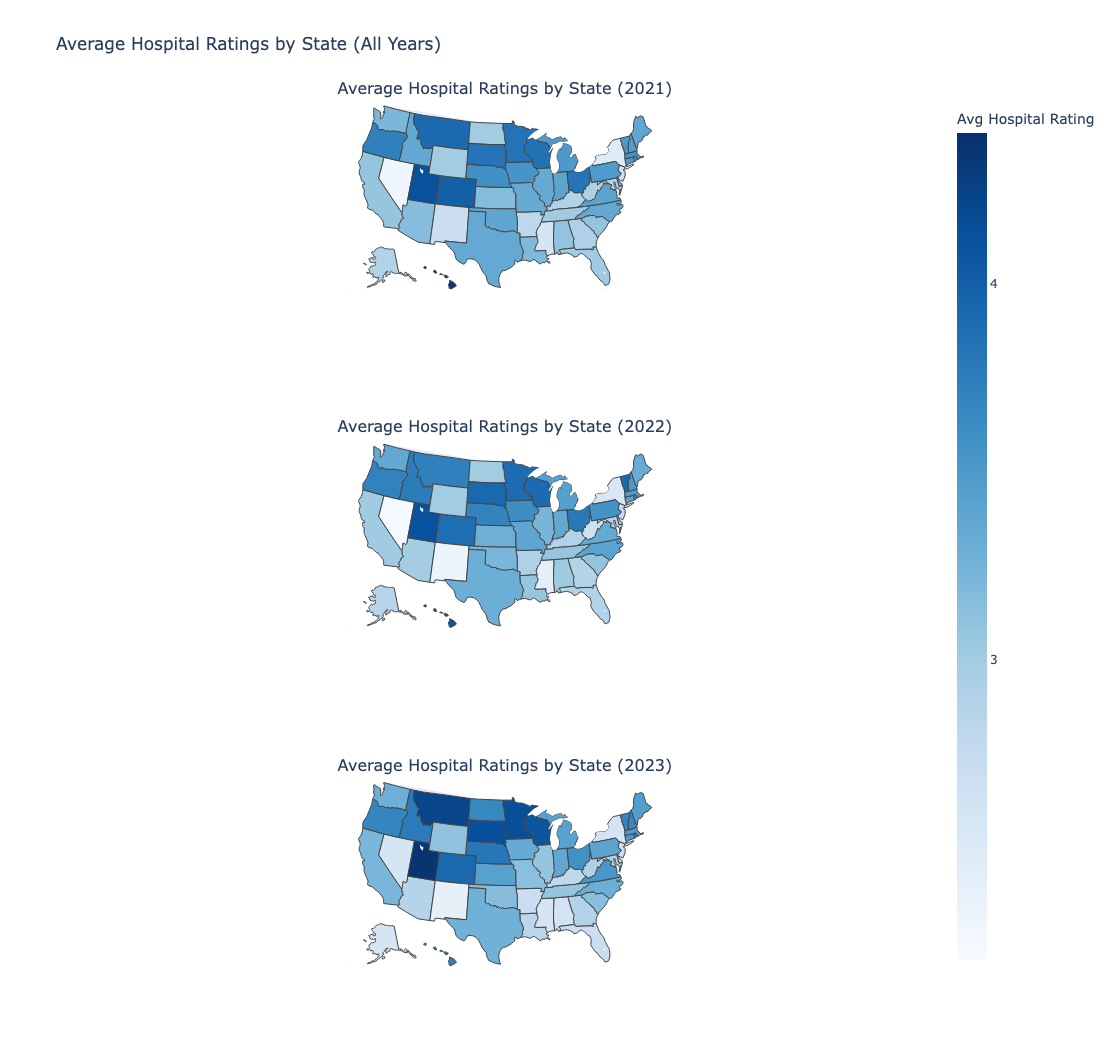

In [54]:
#making choropleth for each year by rating
years = sorted(avg_rankingYear['year'].unique())

fig = make_subplots(
    rows=len(years), cols=1,
    specs=[[{"type": "choropleth"}] for _ in years],
    subplot_titles=[f"Average Hospital Ratings by State ({year})" for year in years]
)

for i, year in enumerate(years, start=1):
    df_year = avg_rankingYear[avg_rankingYear['year'] == year]

    fig.add_trace(
        go.Choropleth(
            locations=df_year['state'],
            z=df_year['avg_hospital_rating'],
            locationmode='USA-states',
            coloraxis="coloraxis", 
            hovertemplate="State: %{location}<br>Avg Rating: %{z:.2f}<extra></extra>"
        ),
        row=i, col=1
    )

# shared color scale
fig.update_layout(
    coloraxis=dict(
        colorscale='Blues',
        cmin=2.2,
        cmax=4.4,         
        colorbar=dict(
            title="Avg Hospital Rating",
            tickmode="array",
            tickvals=[1, 2, 3, 4, 5]
        )
    ),
    title_text="Average Hospital Ratings by State (All Years)",
    height=350 * len(years),
    width=900
)


# apply USA map to each subplot
for i in range(len(years)):
    fig.update_geos(scope='usa', row=i+1, col=1)

#fig.write_html("hospital_ranking_all_years.html")
fig.show()
